---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 15. Ряди та перетворення Фур'є</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Ряди Фур'є</li>
  <li>Узагальнений ряд Фур'є</li>
  <li>Тригонометричний ряд Фур'є</li>
  <li>Тригонометричний ряд Фур'є з полярними координатами</li>
  <li>Спектральна діаграма</li>
  <li>Спектр періодичної послідовності прямокутних імпульсів</li>
  <li>Комплексна форма ряду Фур'є</li>
  <li>Приклад розрахунку тригонометричного ряду Фур'є</li>
  <li>Пряме та зворотне перетворення Фур'є</li>
  <li>Приклад розрахунку перетворення Фур'є</li>
  <li>Приклад використання дискретного перетворення Фур'є для отримання спектру звукового сигналу</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 15 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Ряди Фур'є](#Fourier_series)
    * [Узагальнений ряд Фур'є](#Fourier_series_basic)
    * [🔬 Інтерактивно: наближення прямокутного сигналу рядом Фур'є](#fourier-interactive)
    * [Тригонометричний ряд Фур'є](#Fourier_series_trig)
    * [Тригонометричний ряд Фур'є з полярними координатами](#Fourier_series_polar)
    * [Спектральна діаграма](#spectral-diagram)
    * [Спектр періодичної послідовності прямокутних імпульсів](#pulse-train-spectrum)
    * [🔬 Інтерактивно: вплив шпаруватості на спектр](#pulse-train-interactive)
    * [Комплексна форма ряду Фур'є](#Fourier_series_complex)
    * [Приклад розрахунку тригонометричного ряду Фур'є](#Fourier_series_trig_example)
    * [Пряме та зворотне перетворення Фур'є](#fourier-transform-direct-inverse)
    * [Приклад розрахунку перетворення Фур'є](#fourier-transform-example)
    * [Приклад використання дискретного перетворення Фур'є для отримання спектру звукового сигналу](#Fourier_transform_discrete_microphone)
* [📌 Підсумок теми](#topic-summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Ряди Фур'є <a class="anchor" id="Fourier_series"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Формулювати умови розкладу сигналу в ряд Фур'є
> - Обчислювати коефіцієнти тригонометричного ряду Фур'є
> - Переходити між тригонометричною та комплексною формами
> - Будувати спектральні діаграми (амплітудний та фазовий спектри)
> - Застосовувати ДПФ для спектрального аналізу дискретних сигналів

</div>

### 📐 Форми запису ряду Фур'є

<div style="background-color: #f8fafc; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #475569; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Тригонометрична форма:**
$$s(t) = a_0 + \sum_{n=1}^{\infty}\left[a_n \cos(n\omega_1 t) + b_n \sin(n\omega_1 t)\right]$$

**Полярна (амплітудно-фазова) форма:**
$$s(t) = A_0 + \sum_{n=1}^{\infty} A_n \cos(n\omega_1 t + \varphi_n)$$

**Комплексна (експоненціальна) форма:**
$$s(t) = \sum_{n=-\infty}^{\infty} c_n e^{jn\omega_1 t}$$

</div>



### Узагальнений ряд Фур'є <a class="anchor" id="Fourier_series_basic"></a>

Довільний сигнал $s(t)$ може бути представлений рядом 

$$ s(t) = \sum_{n=-\infty}^{\infty}U_{n}(t)C_{n} $$

де $C_{n}$ - коефіцієнти, що залежать від виду $s(t)$, а $u_{n}$ - $n$-та функція обраного базису $\{u_{n}(t)\}$ , причому базисні функції на інтервалі ортогональності повинні мати властивості: 

1. ортогональності $$ \int_{a}^{b}u_{n}(t)u_{k}(t)dt = 0 $$, за умови $n \neq k $, $[a,b]$ - інтервал ортогональності. 

2. скінченності енергії: $$\int_{a}^{b}u_{n}^{2}(t)dt \neq 0 $$. Величина цієї енергії називається квадратом норми:

$$  \int_{a}^{b}u_{n}^{2}(t)dt  =  || u(t)_{n}||^{2}  $$

Коефіцієнти узагальненого ряду Фур'є визначаються за формулою: 

$$ C_{n} = \cfrac{1}{ || u(t)_{n}||^{2}  } \int_{a}^{b}s(t)u_{n}(t)dt $$

Якщо набір базисних функцій містить комплексні функції, то властивості відображаються таким чином:

$$ \int_{a}^{b}u_{n}(t)u_{k}^{\bullet}(t)dt = 0 $$ для $n \neq k$;

 тут $u_{k}^{\bullet}(t)$ - функція, комплексно спряжена $u_{k}(t)$;
 
$$ \int_{a}^{b}u_{n}(t)u_{k}^{\bullet}(t)dt \neq 0 $$

, а комплексні коефіцієнти ряду визначаються співвідношенням: 

$$ C_{n} = \cfrac{1}{ || u(t)_{n}||^{2}  } \int_{a}^{b}s(t)u_{n}^{+}(t)dt $$



**Енергія сигналу, представленого узагальненим рядом Фур'є.** Оскільки базисні функції ортогональні, енергія сигналу (за узагальненою теоремою Піфагора) дорівнює сумі енергій, внесених кожною складовою окремо — «перехресні» доданки при інтегруванні добутку різних $u_n(t)$ зникають:

$$E = \int_a^b |s(t)|^2\,dt = \sum_{n} |C_n|^2\,\|u_n(t)\|^2$$

Якщо базис ще й **нормований** ($\|u_n(t)\|=1$), формула спрощується до $E=\sum_n|C_n|^2$ — саме такий вигляд має теорема Парсеваля для ряду й перетворення Фур'є, наведена нижче.

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Жан-Батіст Фур'є розробив свою теорію у **1807 році**, досліджуючи не електричні сигнали, а розповсюдження **тепла** у твердих тілах — в оригінальній роботі йдеться саме про «теплові ряди». Ідея, що будь-яку (навіть розривну) функцію можна подати сумою синусоїд, на той час здалася математикам настільки неймовірною, що Лагранж особисто заперечував публікацію статті. Сьогодні саме цей принцип лежить в основі радіомовлення, амплітудної й частотної модуляції, стиснення JPEG/MP3 та цифрової обробки сигналів загалом.


</div>


---
### 🔬 Інтерактивно: наближення прямокутного сигналу рядом Фур'є <a class="anchor" id="fourier-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Збільшуйте кількість гармонік $N$: сума ряду все точніше наближає меандр, але поблизу розривів залишаються викиди ≈ 9 % (**ефект Гіббса**), які не зникають за жодного скінченного $N$.

</div>

In [2]:
# Інтерактивна візуалізація ряду Фур'є: наближення прямокутного сигналу
def fourier_series_interactive(N_terms=5, T=2.0, A=1.0, duty=0.5):
    """Ряд Фур'є для прямокутного сигналу (меандру)"""
    t = np.linspace(0, 2*T, 1000)
    # ідеальний меандр
    f_ideal = np.where((t % T) < duty * T, A, 0.0)

    # наближення рядом Фур'є (лише непарні гармоніки, шпаруватість 2)
    f_approx = np.zeros_like(t)
    omega0 = 2 * np.pi / T
    coeffs = []
    freqs = []
    for n in range(1, N_terms * 2 + 1):
        bn = (2 * A / (n * np.pi)) * np.sin(n * np.pi * duty)  # коефіцієнт ряду Фур'є
        f_approx += bn * np.sin(n * omega0 * t)
        coeffs.append(abs(bn))
        freqs.append(n)
    a0 = A * duty
    f_approx += a0

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(t, f_ideal, 'k--', lw=1.5, label='Ідеальний')
    axes[0].plot(t, f_approx, '#2196F3', lw=2, label=f'N={N_terms} гармонік')
    axes[0].set_xlabel('Час, с'); axes[0].set_ylabel('Амплітуда')
    axes[0].set_title(f'Наближення ряду Фур\'є (N={N_terms})')
    axes[0].legend()

    # амплітудний спектр
    axes[1].bar(freqs, coeffs, color='#4CAF50', edgecolor='k', width=0.6)
    axes[1].set_xlabel('Номер гармоніки n'); axes[1].set_ylabel('|C_n|')
    axes[1].set_title('Амплітудний спектр')

    # похибка залежно від N
    ns = range(1, 20)
    errors = []
    for n_test in ns:
        fa = np.ones_like(t) * A * duty
        for k in range(1, n_test * 2 + 1):
            bk = (2 * A / (k * np.pi)) * np.sin(k * np.pi * duty)
            fa += bk * np.sin(k * omega0 * t)
        errors.append(np.sqrt(np.mean((f_ideal - fa)**2)))
    axes[2].plot(list(ns), errors, '#FF9800', marker='o', ms=5)
    axes[2].axvline(N_terms, color='red', ls='--')
    axes[2].set_xlabel('Кількість гармонік N')
    axes[2].set_ylabel('RMS помилка')
    axes[2].set_title('Збіжність ряду Фур\'є')

    plt.suptitle(f'Ряд Фур\'є: прямокутний сигнал, T={T}с, A={A}, D={duty*100:.0f}%',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    rms_err = np.sqrt(np.mean((f_ideal - f_approx)**2))
    print(f'RMS похибка при N={N_terms}: {rms_err:.4f}')
    print(f'Нульова гармоніка (постійна складова): a0 = {a0:.4f}')
    print(f'Перша гармоніка: b1 = {(2*A/np.pi)*np.sin(np.pi*duty):.4f}')

interact(fourier_series_interactive,
         N_terms=widgets.IntSlider(min=1, max=30, step=1, value=5, description='N гармонік'),
         T=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=2.0, description='T (с)'),
         A=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='Амплітуда'),
         duty=widgets.FloatSlider(min=0.1, max=0.9, step=0.05, value=0.5, description='Шпаруватість'))

interactive(children=(IntSlider(value=5, description='N гармонік', max=30, min=1), FloatSlider(value=2.0, desc…

<function __main__.fourier_series_interactive(N_terms=5, T=2.0, A=1.0, duty=0.5)>

---
### ⚡ Практичне застосування: Ряди та перетворення Фур'є

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Спектральний аналіз у радіотехніці:**

| Застосування | Опис |
|-------------|------|
| **Аналіз модульованих сигналів (AM/FM)** | Спектр АМ-сигналу: несуча + дві бічних смуги |
| **Аналіз гармонічних спотворень (THD)** | $\text{THD} = \sqrt{\sum_{n=2}^N C_n^2}/C_1$ — відношення вищих гармонік до основної |
| **Цифрова обробка сигналів (DSP)** | Швидке перетворення Фур'є (FFT) — основа спектроаналізаторів |
| **Синтез сигналів (DDS)** | Прямий цифровий синтез: таблиця синусів + ряд Фур'є |
| **Фільтрація сигналів** | Множення спектрів у частотній області = згортка у часовій |

**Теорема відліків Котельникова (Найквіста–Шеннона):**
$$f_s \geq 2 f_{max}$$
Мінімальна частота дискретизації вдвічі більша за максимальну частоту в спектрі сигналу.

> **Ефект Гіббса:** При обриві ряду Фур'є на N-й гармоніці поблизу стрибків функції виникають пульсації ~9% від величини стрибка. Не зникають зі збільшенням N, але стають вужчими.

</div>

### Тригонометричний ряд Фур'є  <a class="anchor" id="Fourier_series_trig"></a>

Нехай є періодичний сигнал із періодом $Т$ тобто 

$$ s(t) = s(t+T)$$

Для тригонометричного ряду Фур'є набір базисних функцій має вигляд: 

$$
\{ u(t)_{n}\} = 
\begin{bmatrix}
1 & cos(\omega_{1}t) & cos(2\omega_{1}t) & cos(3\omega_{1}t) & ... & cos(n\omega_{1}t) \\
  & sin(\omega_{1}t) & sin(2\omega_{1}t) & sin(3\omega_{1}t) & ... & sin(n\omega_{1}t) \\
\end{bmatrix}
$$
 
де 
- $\omega_{1} = \cfrac{2\pi}{T}$; $f_{1} = \cfrac{1}{T}$ частота першої гармоніки; 

Частоти $n \cdot \omega_{1}$ або $n \cdot f_{1}$ - частоти вищих гармонійних складових. 

Інтервал ортогональності в цьому випадку дорівнює $Т$. Тригонометричні функції кратних аргументів ортогональні одна одній. 

Квадрат норми базисної функції $u(t)_{0}=1$ дорівнює: 

$$ || u_{0}(t)dt||^{2} = \int_{0}^{T}1^{2}dt = T $$

Квадрат норми для базисних функцій $u_{n}(t)=cos(n \omega_{1} t)$ при $(n \neq 0)$ дорівнює: 

$$ || u(t)_{n}dt||^{2} = \int_{0}^{T}  cos^{2}(n \omega_{1} t) dt = \cfrac{T}{2} $$

Квадрат норми для функцій $u_{n}(t)=sin(n \omega_{1} t)$ при $(n \neq 0)$ дорівнює. 

$$ || u(t)_{n}dt||^{2} = \int_{0}^{T}  sin^{2}(n \omega_{1} t) dt = \cfrac{T}{2} $$
 
Таким чином, коефіцієнти ряду визначаються як:

> $$ C_{0} = a_{0} = \cfrac{1}{T} \cdot \int_{0}^{T}  s(t) \cdot 1 dt $$
> 
> $$ C_{0}^{cos} = a_{n} = \cfrac{2}{T} \cdot \int_{0}^{T}  s(t) \cdot cos(n \omega_{1} t) dt $$
> 
> $$ C_{0}^{sin} = b_{n} = \cfrac{2}{T} \cdot \int_{0}^{T}  s(t) \cdot sin(n \omega_{1} t) dt $$

Тригонометричний ряд Фур'є матиме вигляд: 

 $$
 s(t) = a_{0} + a_{1}\cdot cos(1 \omega_{1} t) + a_{2}\cdot cos(2 \omega_{1} t) + ... + a_{n}\cdot cos(n \omega_{1} t) \newline
 + b_{1}\cdot sin(1 \omega_{1} t) + b_{2}\cdot sin(2 \omega_{1} t) + ... + b_{n}\cdot sin(n \omega_{1} t) \\
 $$

> $$ s(t) = a_{0} + \sum_{n=1}^{\infty} a_{n}\cdot cos(n \omega_{1} t) + b_{n}\cdot sin(n \omega_{1} t) $$



### Тригонометричний ряд Фур'є з полярними координатами  <a class="anchor" id="Fourier_series_polar"></a>

Перетворимо кожну пару з однаковими частотами: 

$$ a_{n}\cdot cos(n \omega_{1} t) + b_{n}\cdot sin(n \omega_{1} t) =  A_{n} \cdot cos(n \omega_{1} t - \alpha_{n})$$

Дійсно:

$$A_{n} \cdot cos(n \omega_{1} t - \alpha_{n}) =   A_{n} \cdot cos(\alpha_{n}) \cdot cos(n \omega_{1} t) + A_{n} \cdot sin(\alpha_{n})\cdot sin(n \omega_{1} t) $$

Таким чином:

$$A_{n} = \sqrt{a_{n}^{2} + b_{n}^{2}}$$

$$\alpha_{n} = arctg \cfrac{b_{n}}{a_{n}}$$

Величину $a_{0}$ можна виразити через загальну формулу для $cos(n \omega_{1} t)$ при $n=0$, тоді $a_{0} = \cfrac{A_{0}}{2}$. 

Позначивши $$ \varphi_{n} = - \alpha_{n} $$, отримуємо відому форму запису тригонометричного ряду Фур'є: 

> $$ s(t) = a_{0} + \sum_{n=1}^{\infty} A_{n} cos(n \omega_{1}t+\varphi_{n}) $$

Для парних функцій $s(t)$ усі непарні члени ряду дорівнюють 0, тобто $b_{n}=0$, отже:

$$A_{n} = a_{n}$$

$$\alpha_{n} = 0$$

Для непарних функцій, усі парні члени ряду дорівнюють 0, тобто всі a_{n}, зокрема й $a_{0}$ дорівнюють 0, отже:

$$A_{n} = b_{n}$$

$$\alpha_{n} = - \cfrac{\pi}{2}$$

Часова інтерпретація тригонометричного ряду Фур'є показана на риcунку. 

Складаючи в кожен момент часу миттєві значення всіх гармонік, отримуємо миттєве значення самого сигналу в цей момент часу. 
 
Знаходження частот, амплітуд і фаз складових сигналу називається **спектральним аналізом**. 

Отримання сигналу за заданими коефіцієнтами $ A_{n} $, фазами $ \varphi_{n} $, і частотами $n\omega_{1}$ називається **синтезом сигналів**. Складаючи обмежену кількість гармонік, отримуємо сигнал, відмінний від того, для якого розраховувалися амплітуди і фази гармонік. 

### Спектральна діаграма <a class="anchor" id="spectral-diagram"></a>

**Спектральною діаграмою** називають графічне представлення набору амплітуд $A_n$ (амплітудна спектральна діаграма) і фаз $\varphi_n$ (фазова спектральна діаграма) гармонік сигналу як функцій частоти $n\omega_1$ — у вигляді окремих вертикальних ліній (ліній спектру) на відповідних частотах, а не неперервної кривої, оскільки спектр періодичного сигналу **дискретний**.


Побудуємо амплітудну та фазову спектральні діаграми меандру:

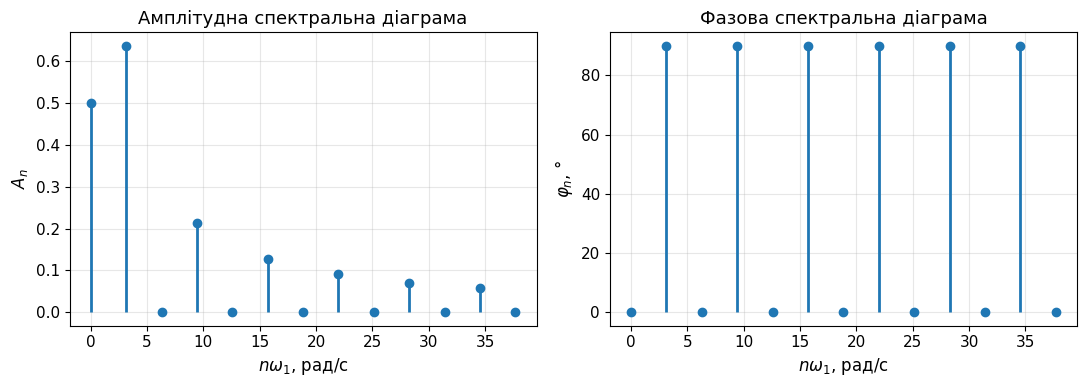

In [3]:
# Спектральна діаграма прямокутного (меандрового) сигналу: амплітудний і фазовий спектри
A_sd, T_sd, duty_sd, N_sd = 1.0, 2.0, 0.5, 12
w1_sd = 2*np.pi/T_sd

ns = np.arange(0, N_sd+1)
An = np.zeros(len(ns)); phin = np.zeros(len(ns))
An[0] = A_sd*duty_sd
for k in ns[1:]:
    an = (A_sd/(k*np.pi))*np.sin(2*np.pi*k*duty_sd)
    bn = (A_sd/(k*np.pi))*(1-np.cos(2*np.pi*k*duty_sd))
    An[k] = np.sqrt(an**2+bn**2)
    phin[k] = np.arctan2(bn, an) if An[k] > 1e-12 else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.stem(ns*w1_sd, An, basefmt=' ')
ax1.set_xlabel(r'$n\omega_1$, рад/с'); ax1.set_ylabel('$A_n$')
ax1.set_title('Амплітудна спектральна діаграма')

ax2.stem(ns*w1_sd, np.degrees(phin), basefmt=' ')
ax2.set_xlabel(r'$n\omega_1$, рад/с'); ax2.set_ylabel(r'$\varphi_n$, °')
ax2.set_title('Фазова спектральна діаграма')
plt.tight_layout(); plt.show()


---
### Спектр періодичної послідовності прямокутних імпульсів <a class="anchor" id="pulse-train-spectrum"></a>

Періодична послідовність прямокутних імпульсів — основний сигнал імпульсної та цифрової техніки. Нехай імпульси мають амплітуду $U$, тривалість $\tau$ і період $T$; відношення $q = T/\tau$ називають **шпаруватістю**, а обернену величину $\tau/T$ — **коефіцієнтом заповнення**. Для послідовності, симетричної відносно $t=0$, всі $b_n = 0$, і ряд Фур'є має вигляд

$$s(t) = \frac{U\tau}{T} + \sum_{n=1}^{\infty} \frac{2U\tau}{T}\,\frac{\sin(n\pi\tau/T)}{n\pi\tau/T}\cos n\omega_1 t$$

Амплітуди гармонік лежать на **обвідній** виду $\left|\dfrac{\sin x}{x}\right|$ з $x = \pi f\tau$:

- обвідна перетворюється на нуль на частотах $f = k/\tau$, $k = 1, 2, \ldots$; якщо шпаруватість $q$ ціла, відсутня кожна $q$-та гармоніка (у меандра, $q = 2$, — усі парні);
- у **головній пелюстці** ($0 < f < 1/\tau$) розміщується $q-1$ гармонік, і в ній зосереджена переважна частина енергії сигналу; тому **практична ширина спектра** $\Delta f \approx 1/\tau$ визначається тривалістю імпульсу, а не періодом;
- за незмінної тривалості $\tau$ і збільшення періоду $T$ лінії спектра розташовуються густіше ($f_1 = 1/T$), а їхні амплітуди зменшуються пропорційно $\tau/T$; форма обвідної не змінюється. При $T\to\infty$ лінійчатий спектр переходить у суцільну спектральну густину одиночного імпульсу (див. перетворення Фур'є нижче).

Висновок для практики: **що коротший імпульс, то ширший спектр** — тому швидкі цифрові сигнали потребують широкосмугових трактів, а для зменшення завад фронти імпульсів затягують.

### 🔬 Інтерактивно: вплив шпаруватості на спектр <a class="anchor" id="pulse-train-interactive"></a>

Змінюйте тривалість імпульсу $\tau$ і період $T$ та спостерігайте, як змінюються густина ліній, амплітуди гармонік і положення нулів обвідної.

In [4]:
# Інтерактивно: спектр періодичної послідовності прямокутних імпульсів
def pulse_train_spectrum(T_ms=4.0, tau_ms=1.0, U=1.0):
    if tau_ms >= T_ms:
        print('Тривалість імпульсу має бути меншою за період: зменшіть τ або збільшіть T.')
        return
    q = T_ms / tau_ms
    f1 = 1 / T_ms                                        # кГц, бо час у мс
    n = np.arange(1, int(np.floor(4 * q)) + 1)           # гармоніки в межах чотирьох пелюсток
    An = 2 * U / q * np.abs(np.sinc(n / q))              # np.sinc(x) = sin(πx)/(πx)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    t = np.linspace(-1.5 * T_ms, 1.5 * T_ms, 3000)
    s = U * (np.mod(t + tau_ms / 2, T_ms) < tau_ms)
    ax1.plot(t, s, color='#2196F3')
    ax1.set_xlabel('t, мс'); ax1.set_ylabel('s(t)')
    ax1.set_title(f'Сигнал: τ = {tau_ms:g} мс, T = {T_ms:g} мс, q = T/τ = {q:.2f}')
    ax1.set_ylim(-0.1 * U, 1.2 * U)

    f_env = np.linspace(0, 4 / tau_ms, 1000)
    ax2.plot(f_env, 2 * U / q * np.abs(np.sinc(f_env * tau_ms)), color='gray', ls='--', lw=1, label='обвідна $\\frac{2U}{q}|\\frac{\\sin x}{x}|$')
    ax2.stem(n * f1, An, basefmt=' ', label='$A_n$')
    ax2.plot(0, U / q, 'o', color='#F44336', label=f'стала складова $U/q$ = {U/q:.3f}')
    for k in range(1, 5):
        ax2.axvline(k / tau_ms, color='#F44336', ls=':', lw=1)
    ax2.set_xlabel('f, кГц'); ax2.set_ylabel('Амплітуда')
    ax2.set_title(f'Спектр: $f_1$ = 1/T = {f1:.3g} кГц, нулі обвідної на k/τ = k·{1/tau_ms:.3g} кГц')
    ax2.legend(fontsize=9); plt.tight_layout(); plt.show()

    in_lobe = int(np.ceil(q) - 1)
    print(f'Гармонік у головній пелюстці: {in_lobe};  практична ширина спектра Δf ≈ 1/τ = {1/tau_ms:.3g} кГц')
    print(f'Амплітуда першої гармоніки A1 = {An[0]:.3f}')

interact(pulse_train_spectrum,
         T_ms=widgets.FloatSlider(min=1, max=10, step=0.5, value=4, description='T (мс)'),
         tau_ms=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description='τ (мс)'),
         U=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1, description='U (В)'));

interactive(children=(FloatSlider(value=4.0, description='T (мс)', max=10.0, min=1.0, step=0.5), FloatSlider(v…

### Комплексна форма ряду Фур'є  <a class="anchor" id="Fourier_series_complex"></a>

Довільну **періодичну функцію** з періодом $T$ можна наблизити довільно точно за допомогою суми комплексних експонент (формула Ейлера):

$$S_N(t) = \sum_{n=-N}^{N} c_n \exp\left( \frac{j 2\pi n t}{T}\right)$$

де **комплексні коефіцієнти Фур'є** $c_n$ визначаються як:

$$c_n = \frac{1}{T} \int_{t_0}^{t_0 + T} f(t) \exp\left( \frac{-j 2\pi n t}{T}\right) dt$$

**Зв'язок з тригонометричними коефіцієнтами:**

$$c_n = \frac{a_n - jb_n}{2}, \quad c_{-n} = \frac{a_n + jb_n}{2}, \quad c_0 = a_0$$

**Двостороннє амплітудно-частотне:** $|c_n| = \frac{1}{2}\sqrt{a_n^2 + b_n^2} = \frac{A_n}{2}$

**Фазово-частотне:** $\angle c_n = -\arctan\frac{b_n}{a_n} = \varphi_n$


### Приклад розрахунку тригонометричного ряду Фур'є  <a class="anchor" id="Fourier_series_trig_example"></a>

4.0*cos(pi*t)/pi**2 + 0.444444444444444*cos(3*pi*t)/pi**2 + 0.16*cos(5*pi*t)/pi**2 + 0.5


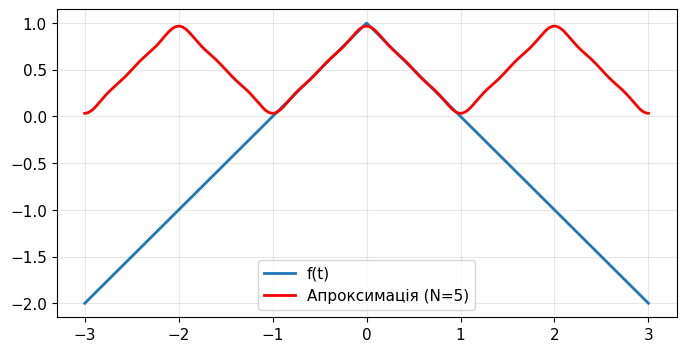

In [5]:
import sympy as smp
i2pi = smp.I*2*smp.pi
exp = smp.exp

def f(t):
    #return -t+smp.Heaviside(t)*t
    #return smp.sin(t)+smp.sin(2*t)+smp.cos(2*t)
    #return (1+1*t) - smp.Heaviside(t)*(1+1*t)  + smp.Heaviside(t)*(1-1*t) 
    return (1+1*t) + smp.Heaviside(t)*(0-2*t) 

    #return -t+smp.Heaviside(t)*t




def a0():
    return 1/T*smp.integrate(
        f(t),
        (t, t0, t0 + T))

def a(n):
    return 2/T*smp.integrate(
        f(t)*smp.cos(2*smp.pi*n*t/T),
        (t, t0, t0 + T))

def b(n):
    return 2/T*smp.integrate(
        f(t)*smp.sin(2*smp.pi*n*t/T),
        (t, t0, t0 + T))

def S(N):
    return a0()+sum( a(n)*smp.cos(n*t*2*smp.pi/T)+b(n)*smp.sin(n*t*2*smp.pi/T) for n in range(1, N+1)).expand(complex=True).simplify()
        
T = 2
t0 = -1

t = smp.Symbol('t', real=True)

N = 5

analytic_approx = S(N).expand()
print(analytic_approx)

interval = (t, t0-T, t0+2*T)

### Тригонометричний ряд Фур'є
t_vals = np.linspace(float(interval[1]), float(interval[2]), 1000)
f_vals = (1 + t_vals) + np.heaviside(t_vals, 0.5) * (0 - 2 * t_vals)
approx_func = smp.lambdify(t, analytic_approx, 'numpy')
approx_vals = approx_func(t_vals)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals, label='f(t)')
plt.plot(t_vals, approx_vals, color='red', label=f'Апроксимація (N={N})')
plt.legend()
plt.show()

---
### Пряме та зворотне перетворення Фур'є <a class="anchor" id="fourier-transform-direct-inverse"></a>

Ряд Фур'є придатний лише для **періодичних** сигналів. Щоб поширити спектральне представлення на **неперіодичний** (одиночний) сигнал, розглядають граничний перехід $T\to\infty$: період прямує до нескінченності, відстань між сусідніми гармоніками $\omega_1=2\pi/T\to0$, дискретний набір частот $n\omega_1$ стає неперервною змінною $\omega$, а сума в комплексному ряді Фур'є переходить в інтеграл. У результаті отримують пару **перетворень Фур'є**:

**Пряме перетворення Фур'є** (від оригіналу $f(t)$ до спектральної густини $F(j\omega)$):
$$F(j\omega) = \int_{-\infty}^{\infty} f(t)\,e^{-j\omega t}\,dt$$

**Обернене (зворотне) перетворення Фур'є** (відновлення оригіналу зі спектра):
$$f(t) = \frac{1}{2\pi}\int_{-\infty}^{\infty} F(j\omega)\,e^{j\omega t}\,d\omega$$

Умова існування (**достатня**): сигнал абсолютно інтегрований, $\int_{-\infty}^{\infty}|f(t)|\,dt<\infty$ (та умови Діріхле на кожному скінченному інтервалі). $F(j\omega)$ у загальному випадку — комплексна функція: $F(j\omega)=|F(j\omega)|\,e^{j\theta(\omega)}$, де $|F(j\omega)|$ — (неперервний) амплітудний спектр, $\theta(\omega)$ — фазовий спектр.

#### Основні властивості перетворення Фур'є <a class="anchor" id="fourier-transform-properties"></a>

| Властивість | Часова область | Частотна область |
|-------------|-----------------|--------------------|
| Лінійність | $a f_1(t)+b f_2(t)$ | $aF_1(j\omega)+bF_2(j\omega)$ |
| Зсув у часі (затримка) | $f(t-t_0)$ | $F(j\omega)\,e^{-j\omega t_0}$ |
| Зсув за частотою (модуляція) | $f(t)\,e^{j\omega_0 t}$ | $F(j(\omega-\omega_0))$ |
| Масштабування | $f(at)$ | $\dfrac{1}{|a|}F\!\left(j\dfrac{\omega}{a}\right)$ |
| Диференціювання | $\dfrac{d f}{dt}$ | $j\omega F(j\omega)$ |
| Інтегрування | $\displaystyle\int_{-\infty}^t f(\tau)d\tau$ | $\dfrac{F(j\omega)}{j\omega}$ (+ доданок з $\delta(\omega)$, якщо $F(0)\neq0$) |
| Згортка в часі | $f_1(t)*f_2(t)$ | $F_1(j\omega)\cdot F_2(j\omega)$ |
| Добуток у часі (дуальність згортки) | $f_1(t)\cdot f_2(t)$ | $\dfrac{1}{2\pi}F_1(j\omega)*F_2(j\omega)$ |
| Симетрія для дійсного $f(t)$ | $f(t)\in\mathbb{R}$ | $F(-j\omega)=F^{*}(j\omega)$ (парний модуль, непарна фаза) |

**Властивість згортки** — ключова для теорії кіл: реакція лінійного кола на вхідний сигнал є згорткою вхідного сигналу з імпульсною характеристикою $y(t)=s(t)*h(t)$ (див. розділ «Динамічне представлення сигналів» вище), тому в частотній області це просто **множення спектрів**: $Y(j\omega)=S(j\omega)H(j\omega)$, де $H(j\omega)$ — частотна характеристика кола.

#### Формула Релея <a class="anchor" id="rayleigh-formula"></a>

**Формула (теорема) Релея** — енергетичний аналог теореми Парсеваля для неперіодичних сигналів: повна енергія сигналу, обчислена в часовій області, дорівнює енергії, обчисленій за його спектром:

$$E = \int_{-\infty}^{\infty}|f(t)|^2\,dt = \frac{1}{2\pi}\int_{-\infty}^{\infty}|F(j\omega)|^2\,d\omega$$

Величину $W(\omega)=|F(j\omega)|^2$ називають **спектральною густиною енергії** — вона показує, як енергія сигналу розподілена за частотою (детальніше — у розділі «Взаємна спектральна густина. Енергетичний спектр» нижче).


Перевіримо формулу Релея чисельно: енергія, обчислена в часовій області, має дорівнювати енергії, обчисленій за спектром.

f(t) = 1.0 В при |t|<0.25 с (прямокутний імпульс)
Енергія в часовій області:      E = A^2*tau       = 0.500000 Дж (на 1 Ом)
Енергія за спектром (формула Релея): E = (1/2π)∫|F|^2 dω = 0.498415 Дж (на 1 Ом)
Збіг підтверджує формулу Релея.


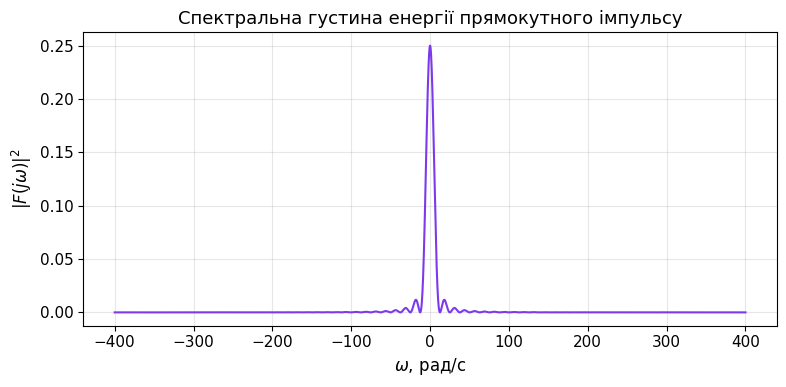

In [6]:
# Перевірка формули Релея на прикладі прямокутного відеоімпульсу
A_r, tau_r = 1.0, 0.5   # амплітуда і тривалість імпульсу f(t) = A, |t|<tau/2

E_time = A_r**2 * tau_r   # енергія в часовій області: інтеграл A^2 на інтервалі tau

w_r = np.linspace(-400, 400, 200000)
F_w = A_r*tau_r*np.sinc(w_r*tau_r/(2*np.pi))   # F(jw) = A*tau*sinc(w*tau/2), np.sinc(x)=sin(pi x)/(pi x)
E_freq = np.trapezoid(np.abs(F_w)**2, w_r) / (2*np.pi)

print(f'f(t) = {A_r} В при |t|<{tau_r/2} с (прямокутний імпульс)')
print(f'Енергія в часовій області:      E = A^2*tau       = {E_time:.6f} Дж (на 1 Ом)')
print(f'Енергія за спектром (формула Релея): E = (1/2π)∫|F|^2 dω = {E_freq:.6f} Дж (на 1 Ом)')
print('Збіг підтверджує формулу Релея.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(w_r, np.abs(F_w)**2, color='#7c3aed', lw=1.5)
ax.set_xlabel(r'$\omega$, рад/с'); ax.set_ylabel(r'$|F(j\omega)|^2$')
ax.set_title('Спектральна густина енергії прямокутного імпульсу')
plt.tight_layout(); plt.show()


### Приклад розрахунку перетворення Фур'є  <a class="anchor" id="fourier-transform-example"></a>

2*sin(t) - sin(2*t) + 2*sin(3*t)/3 - sin(4*t)/2 + 2*sin(5*t)/5


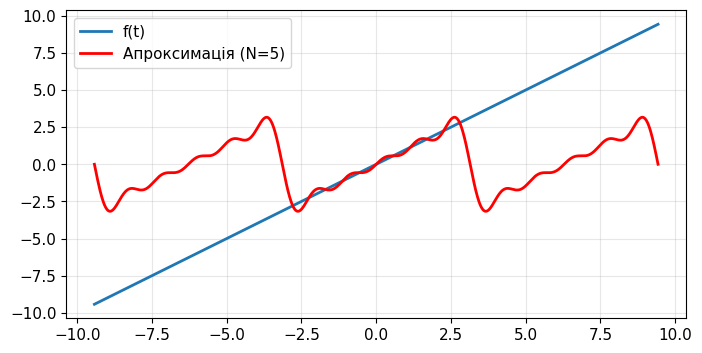

In [7]:
import sympy
i2pi = sympy.I*2*sympy.pi
exp = sympy.exp

def f(t):
    return t

def c(n):
    return (sympy.integrate(
               f(t)*exp((-i2pi * n * t)/P),
               (t, t0, t0 + P))/P)    
def S(N):
    return sum(c(n)*exp(i2pi*n*t/P) for n in range(-N, N+1)).expand(complex=True).simplify()
    
a = sympy.Symbol('a', positive=True)

P = 2*sympy.pi
t0 = -sympy.pi

t = sympy.Symbol('t', real=True)

N = 5

analytic_approx = S(N).expand()
print(analytic_approx)

interval = (t, t0-P, t0+2*P)
t_vals = np.linspace(float(interval[1]), float(interval[2]), 1000)
f_vals = t_vals
approx_func = sympy.lambdify(t, analytic_approx, 'numpy')
approx_vals = approx_func(t_vals)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals, label='f(t)')
plt.plot(t_vals, approx_vals, color='red', label=f'Апроксимація (N={N})')
plt.legend()
plt.show()

### Приклад використання дискретного перетворення Фур'є для отримання спектру звукового сигналу   <a class="anchor" id="Fourier_transform_discrete_microphone"></a>

Під час локального запуску з мікрофоном (потрібен пакет `sounddevice`: `pip install sounddevice`) з'явиться кнопка запису — проспівайте або зіграйте ноту і знайдіть її основний тон та гармоніки. В онлайн-середовищі (Binder) мікрофон недоступний, тому аналізується синтезований акорд.

Мікрофон недоступний — аналізуємо синтезований акорд.


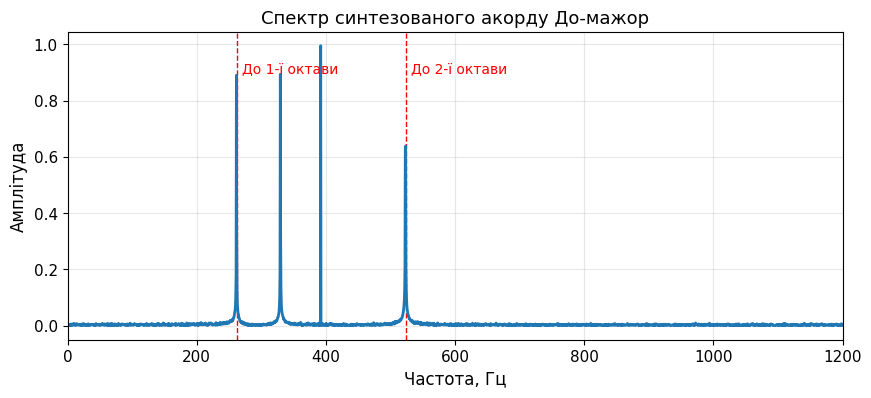

In [8]:
# Спектр звукового сигналу за допомогою ДПФ (np.fft).
# Якщо доступний мікрофон (локальний запуск і встановлено пакет sounddevice) — записуємо звук.
# Інакше (наприклад, у Binder) — синтезуємо акорд До-мажор (До, Мі, Соль 1-ї октави + До 2-ї октави) з шумом.
duration = 2         # тривалість запису, с
sample_rate = 44100  # частота дискретизації, Гц

try:
    import sounddevice as sd
    sd.query_devices(kind='input')
    MIC_AVAILABLE = True
except Exception:
    MIC_AVAILABLE = False

def capture_audio(duration, sample_rate):
    audio = sd.rec(int(duration*sample_rate), samplerate=sample_rate, channels=1, dtype='float64')
    sd.wait()
    return audio.flatten()

def synth_audio(duration, sample_rate):
    t = np.arange(int(duration*sample_rate))/sample_rate
    notes = [261.63, 329.63, 392.00, 523.25]   # До1, Мі1, Соль1, До2, Гц
    rng = np.random.default_rng(0)
    return sum(np.sin(2*np.pi*f*t) for f in notes) + 0.5*rng.standard_normal(t.size)

def compute_fft(audio_data, sample_rate):
    n = len(audio_data)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)
    amps = 2*np.abs(np.fft.rfft(audio_data))/n     # амплітуди гармонік
    return freqs, amps

def plot_spectrum(freqs, amps, title, max_freq=1200):
    plt.figure(figsize=(10, 4))
    for f, name in [(262, 'До 1-ї октави'), (524, 'До 2-ї октави')]:
        plt.axvline(f, color='r', ls='--', lw=1)
        plt.text(f + 8, 0.9*amps[freqs < max_freq].max(), name, color='r', fontsize=10)
    plt.plot(freqs, amps)
    plt.title(title)
    plt.xlabel('Частота, Гц'); plt.ylabel('Амплітуда')
    plt.xlim(0, max_freq)
    plt.show()

if MIC_AVAILABLE:
    out = widgets.Output()
    def on_button_clicked(b):
        with out:
            out.clear_output()
            print('Запис...')
            freqs, amps = compute_fft(capture_audio(duration, sample_rate), sample_rate)
            plot_spectrum(freqs, amps, 'Спектр сигналу з мікрофона')
    button = widgets.Button(description='Почати запис')
    button.on_click(on_button_clicked)
    display(button, out)
else:
    print('Мікрофон недоступний — аналізуємо синтезований акорд.')
    freqs, amps = compute_fft(synth_audio(duration, sample_rate), sample_rate)
    plot_spectrum(freqs, amps, 'Спектр синтезованого акорду До-мажор')

---
### ✅ Питання для самоперевірки: Ряди та перетворення Фур'є

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Яка умова існування ряду Фур'є для функції f(t)?</summary>

> **Відповідь:** Умови Діріхле: f(t) — обмежена, має скінченну кількість максимумів, мінімумів і точок розриву 1-го роду на кожному обмеженому інтервалі. На практиці всі фізично реальні сигнали задовольняють ці умови.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому спектр парної функції містить лише косинусні складові?</summary>

> **Відповідь:** Для парної $f(t) = f(-t)$ всі коефіцієнти $b_n = 0$, оскільки $b_n = \frac{2}{T}\int_0^T f(t)\sin(n\omega_0 t)dt = 0$ (добуток парної та непарної функцій — непарна, інтеграл по симетричному відрізку = 0).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що таке теорема Парсеваля і як вона пов'язана з енергією сигналу?</summary>

> **Відповідь:** $\frac{1}{T}\int_0^T |f(t)|^2 dt = \sum_{n=-\infty}^{\infty} |C_n|^2$ — потужність сигналу дорівнює сумі квадратів модулів комплексних коефіцієнтів Фур'є. Кожна гармоніка вносить незалежний внесок у потужність.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4 (поглиблений).</b> Яка різниця між рядом Фур'є та перетворенням Фур'є?</summary>

> **Відповідь:** Ряд Фур'є — для **періодичних** сигналів, дає дискретний спектр із гармонічними складовими. Перетворення Фур'є — для **неперіодичних** (або одиночних) сигналів, дає неперервний спектр $F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-j\omega t} dt$.

</details>

---
### 📝 Задачі для самостійного розв'язання: Ряди та перетворення Фур'є


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Меандр (±1 В) розкладається в ряд $\dfrac{4}{\pi}\sum\limits_{n=1,3,5\ldots}\dfrac{\sin n\omega t}{n}$. Знайдіть амплітуди 1-ї, 3-ї та 5-ї гармонік і частку потужності, що припадає на першу гармоніку.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $A_1 = 4/\pi \approx 1{,}273$ В, $A_3 \approx 0{,}424$ В, $A_5 \approx 0{,}255$ В. Потужність меандру $1$ В², першої гармоніки $A_1^2/2 \approx 0{,}81$ — тобто $\approx 81\,\%$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Прямокутний відеоімпульс $A = 1$ В, $\tau = 1$ мс. Знайдіть $S(0)$, першу нульову частоту спектра та енергію. Яка частка енергії зосереджена в головній пелюстці $|f| < 1/\tau$?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $S(0) = A\tau = 10^{-3}$ В·с; перший нуль на $f = 1/\tau = 1$ кГц; $E = A^2\tau = 10^{-3}$ В²·с. За формулою Релея, інтегруючи $|S(f)|^2$ в межах головної пелюстки, отримуємо $\approx 90\,\%$ енергії — звідси практична оцінка ширини спектра $\Delta f \approx 1/\tau$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Періодична послідовність прямокутних імпульсів: амплітуда $U = 5$ В, тривалість $\tau = 10$ мкс, період $T = 40$ мкс. Знайдіть шпаруватість, сталу складову, частоту й амплітуду першої гармоніки, номери гармонік, що дорівнюють нулю, і практичну ширину спектра.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $q = T/\tau = 4$; стала складова $U/q = 1{,}25$ В; $f_1 = 1/T = 25$ кГц; $A_1 = \dfrac{2U}{q}\,\dfrac{\sin(\pi/4)}{\pi/4} \approx 2{,}5\cdot0{,}900 = 2{,}25$ В. Нульові гармоніки — кожна четверта: $n = 4, 8, \ldots$ (100, 200 кГц, …). Головна пелюстка містить 3 гармоніки, $\Delta f \approx 1/\tau = 100$ кГц.

</details>


---

### 📌 Підсумок теми <a class="anchor" id="topic-summary"></a>

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Поняття | Формула |
|---|---|
| Тригонометричний ряд | $s(t) = a_0 + \sum\limits_{n=1}^{\infty}\left(a_n\cos n\omega_1 t + b_n\sin n\omega_1 t\right)$, $\;\omega_1 = 2\pi/T$ |
| Коефіцієнти | $a_0 = \dfrac1T\displaystyle\int_T s\,dt$, $\;a_n = \dfrac2T\displaystyle\int_T s\cos n\omega_1 t\,dt$, $\;b_n = \dfrac2T\displaystyle\int_T s\sin n\omega_1 t\,dt$ |
| Амплітудно-фазова форма | $A_n = \sqrt{a_n^2+b_n^2}$, $\;s(t) = A_0 + \sum A_n\cos(n\omega_1 t + \varphi_n)$ |
| Комплексна форма | $s(t) = \sum\limits_{n=-\infty}^{\infty} c_n e^{jn\omega_1 t}$, $\;c_n = \dfrac1T\displaystyle\int_T s\,e^{-jn\omega_1 t}dt$, $\;\vert c_n\vert = A_n/2$ |
| Пряме / зворотне перетворення Фур'є | $F(j\omega) = \displaystyle\int_{-\infty}^{\infty} f(t)e^{-j\omega t}dt$, $\;f(t) = \dfrac{1}{2\pi}\displaystyle\int_{-\infty}^{\infty} F(j\omega)e^{j\omega t}d\omega$ |
| Формула Релея | $E = \displaystyle\int \vert f(t)\vert^2dt = \dfrac{1}{2\pi}\displaystyle\int \vert F(j\omega)\vert^2 d\omega$ |
| Послідовність прямокутних імпульсів | $A_n = \dfrac{2U}{q}\left\vert\dfrac{\sin(n\pi/q)}{n\pi/q}\right\vert$, $\;q = T/\tau$, $\;\Delta f \approx 1/\tau$ |

**Головні висновки.** (1) Періодичний сигнал має дискретний (лінійчатий) спектр з кроком $f_1 = 1/T$, неперіодичний — суцільну спектральну густину. (2) Ширина спектра обернено пропорційна тривалості сигналу: $\tau\,\Delta f \approx 1$. (3) Згортка в часі відповідає множенню спектрів, тому дію лінійного кола на сигнал зручно аналізувати в частотній області. (4) ДПФ дозволяє чисельно знайти спектр дискретизованого сигналу.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 14. Радіотехнічні сигнали. Елементи функціонального аналізу](Тема_14_Радіотехнічні_сигнали.ipynb) &nbsp;|&nbsp; [Тема 16. Кореляційний аналіз та модуляція сигналів](Тема_16_Кореляційний_аналіз_та_модуляція.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
